# Notebook 09 — Ensemble & Submission Generation
Blend baseline + ML models, select best strategy, run iterative prediction for test set (548 days), and produce submission.csv.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from src.utils import load_config, set_seed, ensure_dirs, save_submission
from src.data_loader import load_all, load_sample_submission
from src.models.gbm import load_model, get_feature_cols
from src.models.ensemble import compare_blend_strategies, blend_predictions, optimize_weights_balanced
from src.features.pipeline import build_feature_matrix
from src.metrics import evaluate

cfg = load_config('../config.yaml')
cfg['paths']['dataset']     = '../dataset'
cfg['paths']['outputs']     = '../outputs'
cfg['paths']['figures']     = '../outputs/figures'
cfg['paths']['models']      = '../outputs/models'
cfg['paths']['cv_results']  = '../outputs/cv_results'
cfg['paths']['submissions'] = '../outputs/submissions'
cfg['paths']['report_figures'] = '../report/figures'

set_seed(cfg['seed'])
ensure_dirs(cfg)
print('Config loaded.')

Config loaded.


In [2]:
# Load predictions from previous notebooks
baseline_path = cfg['paths']['cv_results'] + '/baseline_preds.csv'
ml_path       = cfg['paths']['cv_results'] + '/ml_preds.csv'

baseline_preds = pd.read_csv(baseline_path, parse_dates=['Date'])
ml_preds       = pd.read_csv(ml_path, parse_dates=['Date'])

# Merge on Date
all_preds = baseline_preds.merge(ml_preds[['Date', 'LGBM_L1', 'LGBM_L2', 'LGBM_Huber']], on='Date')
print(f'Combined predictions shape: {all_preds.shape}')
print(all_preds.head())

Combined predictions shape: (365, 7)
        Date      Actual  SeasonalNaive_lag365    EMA_span30       LGBM_L1  \
0 2022-01-01  2932155.47            1553431.51  1.919239e+06  1.945003e+06   
1 2022-01-02  2361965.00             378420.41  1.919239e+06  1.698851e+06   
2 2022-01-03   545563.72             677894.56  1.919239e+06  1.403913e+06   
3 2022-01-04  1242319.38             819877.04  1.919239e+06  9.648061e+05   
4 2022-01-05   809977.60            1174326.91  1.919239e+06  1.173647e+06   

        LGBM_L2    LGBM_Huber  
0  2.064561e+06  4.400352e+06  
1  1.635352e+06  4.400352e+06  
2  1.138973e+06  4.400352e+06  
3  1.004709e+06  4.400352e+06  
4  1.040037e+06  4.400352e+06  


In [3]:
# Compare blend strategies on val set (using ML models + SeasonalNaive)
y_val = all_preds['Actual'].values

# Predictions list: all 5 models
preds_list = [
    all_preds['SeasonalNaive_lag365'].values,
    all_preds['EMA_span30'].values,
    all_preds['LGBM_L1'].values,
    all_preds['LGBM_L2'].values,
    all_preds['LGBM_Huber'].values,
]
model_names = ['SeasonalNaive', 'EMA30', 'LGBM-L1', 'LGBM-L2', 'LGBM-Huber']

print('Comparing blend strategies...')
blend_df = compare_blend_strategies(preds_list, y_val, model_names, seed=cfg['seed'])
print('\n=== Blend Strategy Comparison ===')
display(blend_df.style.format({
    'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.4f}', 'Composite': '{:.4f}'
}))

[10:25:01] INFO ensemble: Optimal weights: ['0.000', '0.000', '0.000', '0.931', '0.069']


Comparing blend strategies...
[Ensemble (optimal weights)]  MAE=549,288  RMSE=747,145  R2=0.8008  Composite=0.3497


[10:25:01] INFO ensemble: Optimal weights: ['0.000', '0.000', '0.000', '0.933', '0.067']
[10:25:01] INFO ensemble: Optimal weights: ['0.000', '0.000', '0.000', '0.936', '0.064']


[Ensemble (optimal weights)]  MAE=549,336  RMSE=747,071  R2=0.8008  Composite=0.3497
[Ensemble (optimal weights)]  MAE=549,461  RMSE=747,036  R2=0.8008  Composite=0.3497

=== Blend Strategy Comparison ===


,Strategy,MAE,RMSE,R2,Composite
2,Blend (Balanced),"549,336","747,071",0.8008,0.3497
1,Blend (MAE-heavy),"549,288","747,145",0.8008,0.3497
3,Blend (RMSE-heavy),"549,461","747,036",0.8008,0.3497
7,LGBM-L2,"566,102","757,959",0.7949,0.3574
6,LGBM-L1,"573,657","798,593",0.7724,0.3735
0,Equal Weight,"760,858","999,304",0.6436,0.4919
4,SeasonalNaive,"837,704","1,161,819",0.5182,0.5742
5,EMA30,"1,514,086","2,110,518",-0.5899,1.1842
8,LGBM-Huber,"1,746,007","2,056,928",-0.5102,1.2108


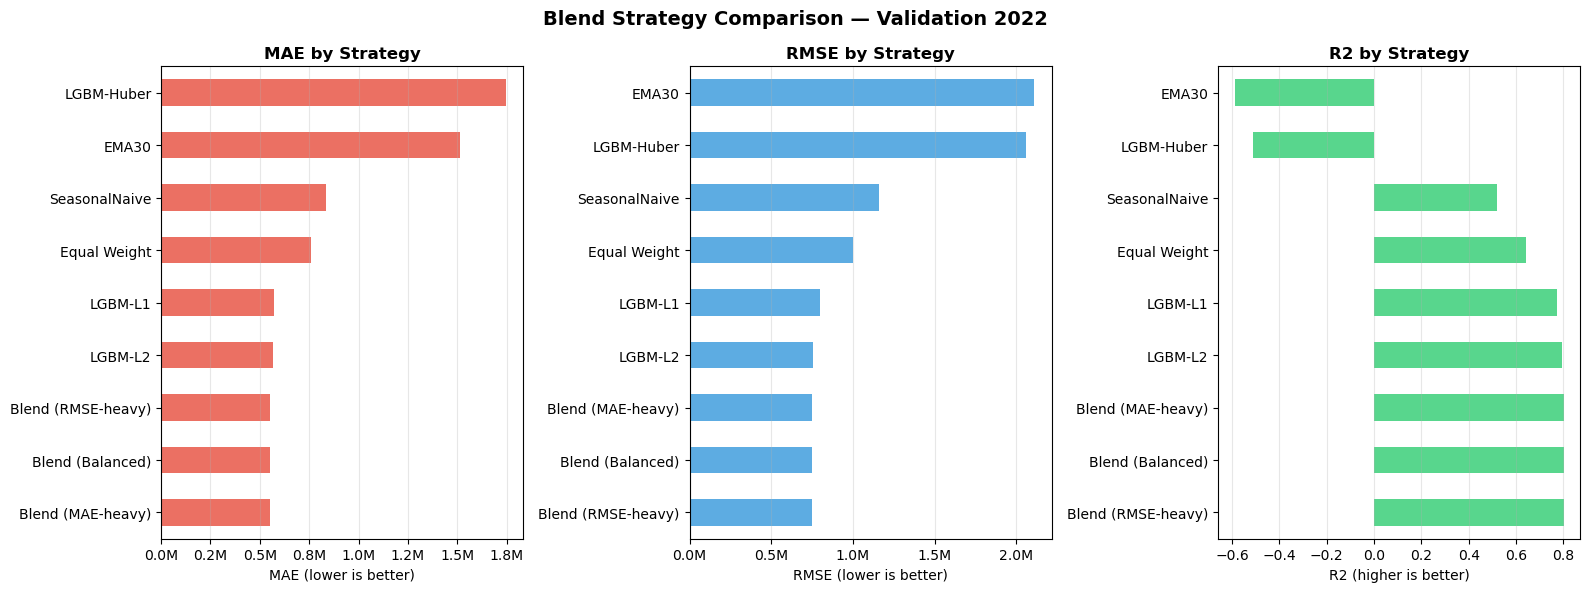

Saved: ../outputs/figures/09_ensemble_comparison.png


In [4]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics_plot = ['MAE', 'RMSE', 'R2']
colors_list  = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, color in zip(axes, metrics_plot, colors_list):
    plot_data = blend_df.set_index('Strategy')[metric]
    if metric == 'R2':
        plot_data.sort_values(ascending=False).plot(kind='barh', ax=ax, color=color, alpha=0.8)
        ax.set_xlabel('R2 (higher is better)')
    else:
        plot_data.sort_values(ascending=True).plot(kind='barh', ax=ax, color=color, alpha=0.8)
        ax.set_xlabel(f'{metric} (lower is better)')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.set_title(f'{metric} by Strategy', fontweight='bold')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Blend Strategy Comparison — Validation 2022', fontsize=14, fontweight='bold')
plt.tight_layout()

fig_path = cfg['paths']['figures'] + '/09_ensemble_comparison.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [5]:
# Get optimized balanced weights
print('\nOptimizing balanced weights...')
ml_preds_list = [
    all_preds['LGBM_L1'].values,
    all_preds['LGBM_L2'].values,
    all_preds['LGBM_Huber'].values,
]

balanced_weights, balanced_metrics = optimize_weights_balanced(
    ml_preds_list, y_val, seed=cfg['seed']
)

print(f'\nBalanced weights (L1, L2, Huber): {[f"{w:.3f}" for w in balanced_weights]}')
print(f'Ensemble MAE : {balanced_metrics["mae"]:,.0f}')
print(f'Ensemble RMSE: {balanced_metrics["rmse"]:,.0f}')
print(f'Ensemble R2  : {balanced_metrics["r2"]:.4f}')

[10:25:01] INFO ensemble: Optimal weights: ['0.000', '0.933', '0.067']



Optimizing balanced weights...
[Ensemble (optimal weights)]  MAE=549,336  RMSE=747,071  R2=0.8008  Composite=0.3497

Balanced weights (L1, L2, Huber): ['0.000', '0.933', '0.067']
Ensemble MAE : 549,336
Ensemble RMSE: 747,071
Ensemble R2  : 0.8008


In [6]:
# Load feature matrix for iterative test prediction
FEAT_PATH = '../outputs/feature_matrix.parquet'
if Path(FEAT_PATH).exists():
    df = pd.read_parquet(FEAT_PATH)
else:
    tables = load_all(cfg)
    df = build_feature_matrix(cfg, tables, save_path=FEAT_PATH)

print(f'Feature matrix: {df.shape}')

# Load models
m_l1  = load_model('lgbm_l1',    cfg['paths']['models'])
m_l2  = load_model('lgbm_l2',    cfg['paths']['models'])
m_hub = load_model('lgbm_huber', cfg['paths']['models'])
print('Models loaded.')

feat_cols = get_feature_cols(df)

Feature matrix: (4381, 220)
Models loaded.


In [7]:
# COGS ratio from last 90 days of training data
train_data = df[df['Date'] <= '2022-12-31'].copy()
cogs_ratio = (
    (train_data['COGS'] / (train_data['Revenue'] + 1e-6))
    .rolling(90, min_periods=30).mean().iloc[-1]
)
print(f'COGS/Revenue ratio (rolling 90d): {cogs_ratio:.4f}')

# Test set dates
sample_sub = load_sample_submission(cfg)
test_dates = sample_sub['Date'].sort_values().values
print(f'Test set: {len(test_dates)} days ({pd.Timestamp(test_dates[0]).date()} to {pd.Timestamp(test_dates[-1]).date()})')

COGS/Revenue ratio (rolling 90d): 0.9165
Test set: 548 days (2023-01-01 to 2024-07-01)


In [8]:
# Iterative prediction for test set
# For each test day: build features from history, predict Revenue, update history

# Prepare history with all known data
history = df[df['Date'] <= '2022-12-31'].copy()

test_revenue_preds = []
test_cogs_preds    = []

print(f'Running iterative prediction for {len(test_dates)} test days...')

for i, test_date in enumerate(test_dates):
    # Get the row from df for this test date (pre-computed features)
    row = df[df['Date'] == test_date]

    if len(row) == 0:
        # Fallback: use last known value
        rev_pred = history['Revenue'].iloc[-1]
    else:
        X_row = row[feat_cols].fillna(0)
        # Ensemble predict
        preds_row = [
            m_l1.predict(X_row)[0],
            m_l2.predict(X_row)[0],
            m_hub.predict(X_row)[0],
        ]
        rev_pred = float(blend_predictions(
            [np.array([p]) for p in preds_row],
            balanced_weights
        )[0])

    rev_pred  = max(0.0, rev_pred)
    cogs_pred = max(0.0, rev_pred * cogs_ratio)

    test_revenue_preds.append(rev_pred)
    test_cogs_preds.append(cogs_pred)

    # Update history row so lagged features pick up this prediction
    new_row = pd.DataFrame([{
        'Date': pd.Timestamp(test_date),
        'Revenue': rev_pred,
        'COGS': cogs_pred
    }])
    history = pd.concat([history, new_row], ignore_index=True)

    if (i + 1) % 100 == 0 or i == 0:
        print(f'  {i+1}/{len(test_dates)} done | last rev_pred={rev_pred:,.0f}')

print(f'Iterative prediction complete. {len(test_revenue_preds)} predictions made.')

Running iterative prediction for 548 test days...
  1/548 done | last rev_pred=1,824,819
  100/548 done | last rev_pred=2,792,871
  200/548 done | last rev_pred=3,067,615
  300/548 done | last rev_pred=2,675,862
  400/548 done | last rev_pred=2,199,434
  500/548 done | last rev_pred=2,371,419
Iterative prediction complete. 548 predictions made.


In [9]:
# Build submission DataFrame matching sample_submission order
pred_df = pd.DataFrame({
    'Date':    pd.to_datetime(test_dates),
    'Revenue': test_revenue_preds,
    'COGS':    test_cogs_preds,
})

# Re-order to match sample_submission
submission = sample_sub[['Date']].copy()
submission = submission.merge(pred_df, on='Date', how='left')

# Clip negatives
submission['Revenue'] = submission['Revenue'].clip(lower=0)
submission['COGS']    = submission['COGS'].clip(lower=0)

print('=== Submission Validation ===')
print(f'Rows           : {len(submission)}')
print(f'NaN Revenue    : {submission["Revenue"].isna().sum()}')
print(f'NaN COGS       : {submission["COGS"].isna().sum()}')
print(f'Negative Rev   : {(submission["Revenue"] < 0).sum()}')
print(f'Negative COGS  : {(submission["COGS"] < 0).sum()}')
print(f'Revenue range  : {submission["Revenue"].min():,.0f} — {submission["Revenue"].max():,.0f}')
print(f'COGS range     : {submission["COGS"].min():,.0f} — {submission["COGS"].max():,.0f}')
assert len(submission) == 548, f'Expected 548 rows, got {len(submission)}'
assert submission['Revenue'].isna().sum() == 0, 'Revenue has NaN'
assert submission['COGS'].isna().sum() == 0, 'COGS has NaN'
print('\nAll checks passed.')

=== Submission Validation ===
Rows           : 548
NaN Revenue    : 0
NaN COGS       : 0
Negative Rev   : 0
Negative COGS  : 0
Revenue range  : 1,609,857 — 3,787,502
COGS range     : 1,475,411 — 3,471,190

All checks passed.


Submission saved: ../outputs/submissions/submission_v01_balanced.csv


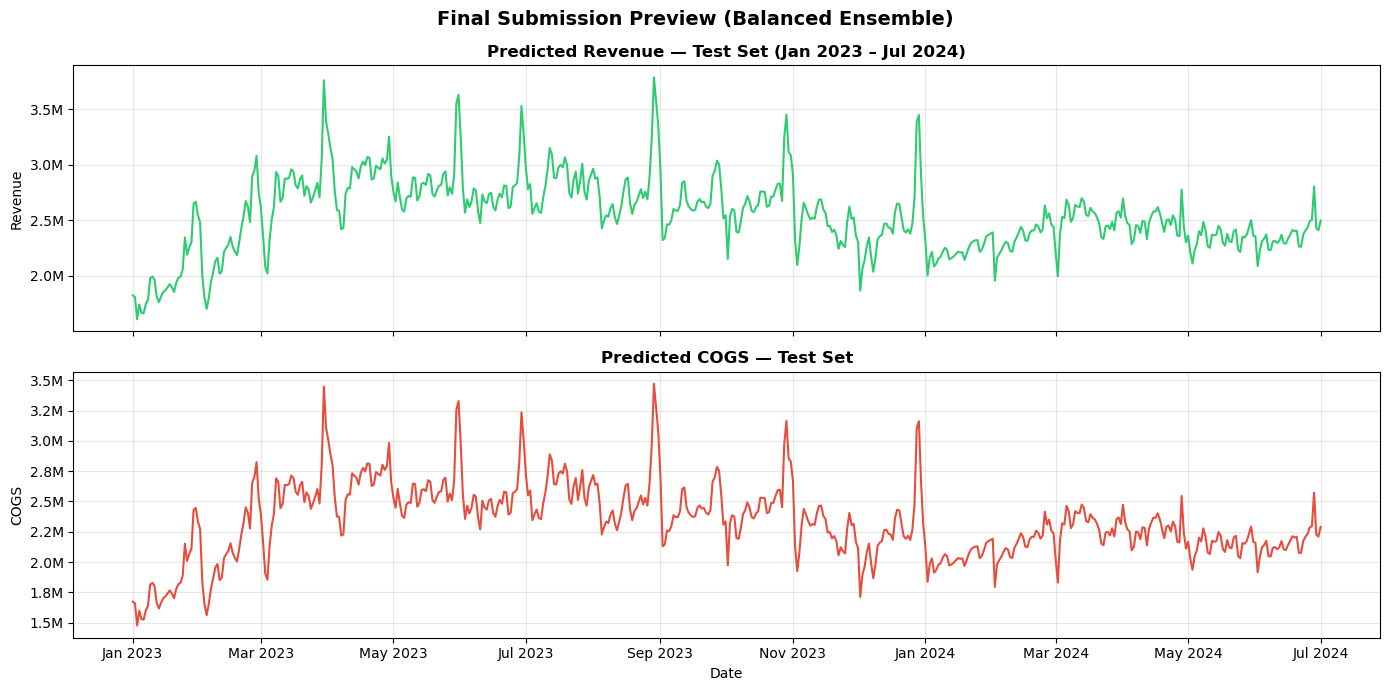

Saved: ../outputs/figures/09_submission_preview.png

Ensemble & submission notebook complete.


In [10]:
# Save submission
sub_path = cfg['paths']['submissions'] + '/submission_v01_balanced.csv'
submission.to_csv(sub_path, index=False)
print(f'Submission saved: {sub_path}')

# Plot submission preview
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(submission['Date'], submission['Revenue'], color='#2ecc71', lw=1.5)
axes[0].set_title('Predicted Revenue — Test Set (Jan 2023 – Jul 2024)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue')
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].plot(submission['Date'], submission['COGS'], color='#e74c3c', lw=1.5)
axes[1].set_title('Predicted COGS — Test Set', fontsize=12, fontweight='bold')
axes[1].set_ylabel('COGS')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Final Submission Preview (Balanced Ensemble)', fontsize=14, fontweight='bold')
plt.tight_layout()

fig_path = cfg['paths']['figures'] + '/09_submission_preview.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')
print('\nEnsemble & submission notebook complete.')